# Step 4: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Step 5: Load Dataset

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


# Step 6: Understand the Dataset

In [4]:
print(df.shape)

(20640, 9)


# Step 7: Basic Exploration

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [6]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [7]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


# Step 8: Visualize Data
### Histogram

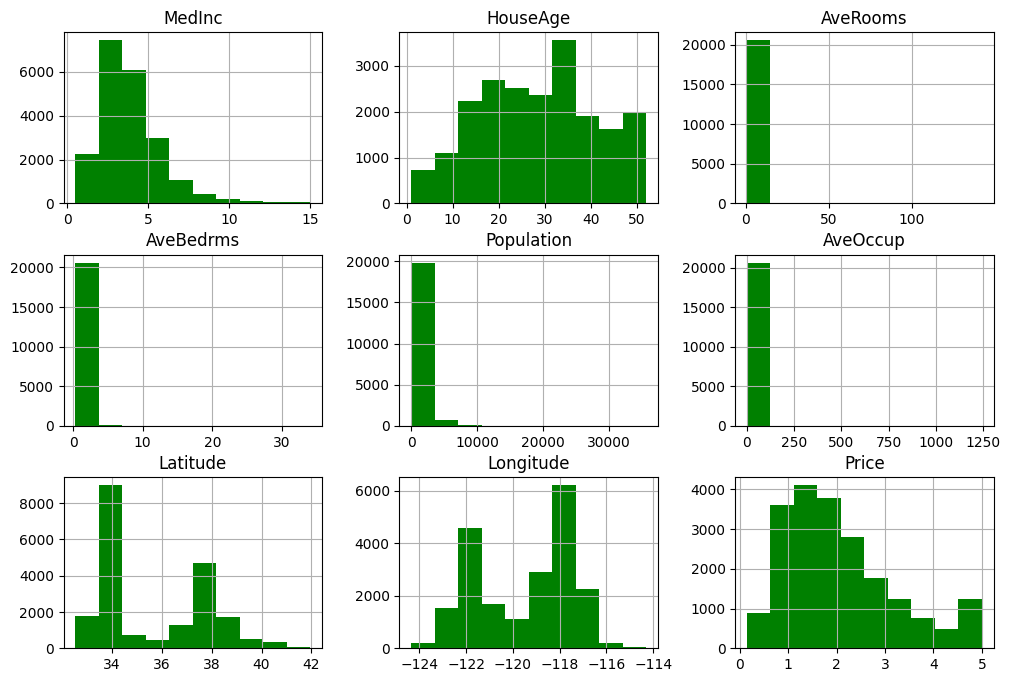

In [10]:
df.hist(figsize=(12, 8), color="green")
plt.show()

### Correlation Heatmap

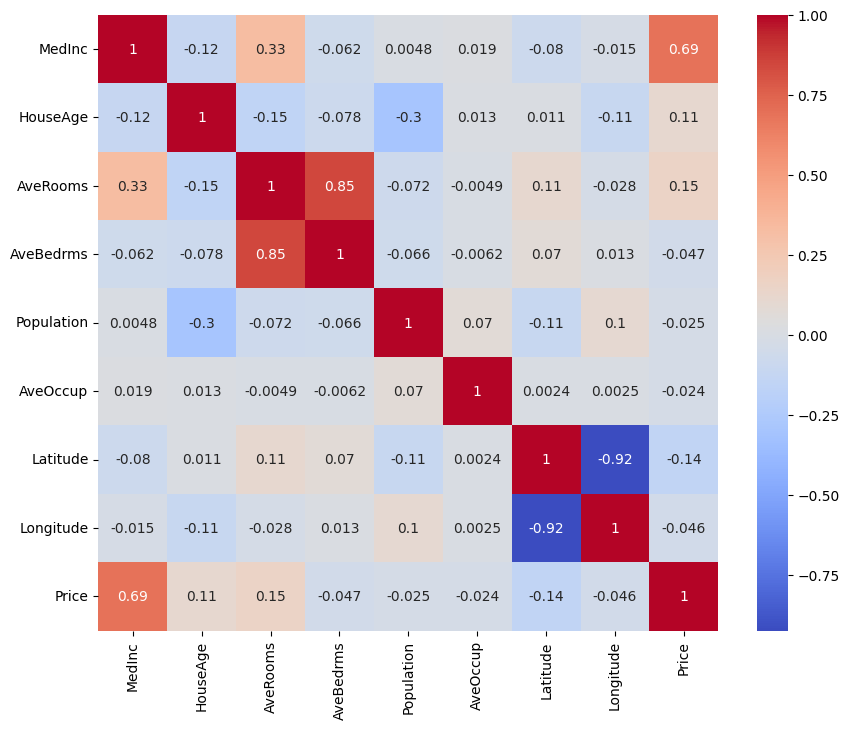

In [11]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Step 9: Define Features and Target

In [12]:
X = df.drop("Price", axis=1)

y = df["Price"]

# Step 10: Train-Test Split

80% Training

20% Testing

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 11: Train Model

Use Linear Regression.

In [14]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

# Step 12: Make Predictions

In [21]:
predictions = model.predict(X_test)

print(predictions[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


# Step 13: Evaluate Model
MAE

In [22]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print(mae)

0.533200130495656


MSE

In [23]:
mse = mean_squared_error(
    y_test,
    predictions
)

print(mse)

0.5558915986952438


R² Score

In [24]:
r2 = r2_score(
    y_test,
    predictions
)

print(r2)

0.5757877060324512


# Step 14: Visualize Predictions

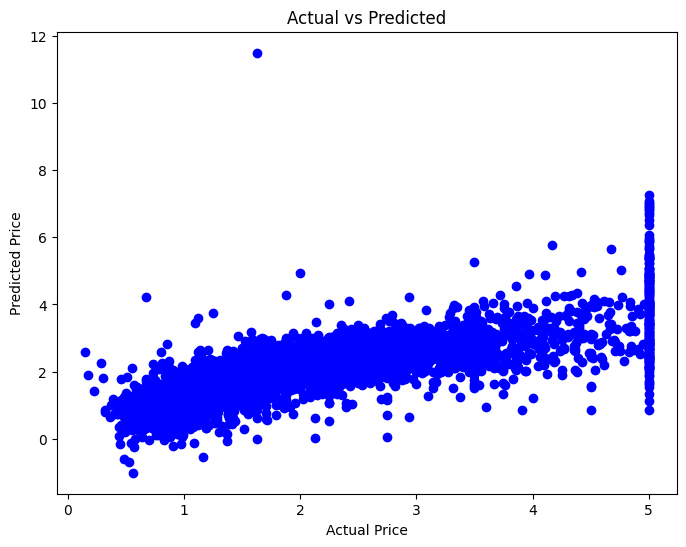

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, color="blue")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

# Step 15: Predict a New House

In [40]:
new_house = [[
    8.5,
    20,
    6,
    1,
    1000,
    3,
    37,
    -122
]]

price = model.predict(new_house)

print(f"Predicted price: {price[0]:.2f}")

Predicted price: 4.40


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Step 16: Save the Model

In [41]:
import joblib

joblib.dump(
    model,
    "house_price_model.pkl"
)

['house_price_model.pkl']

# Step 17: Load the Model

In [42]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)

# **Complete Copy-Paste Code**